# Explain Like I'm 5

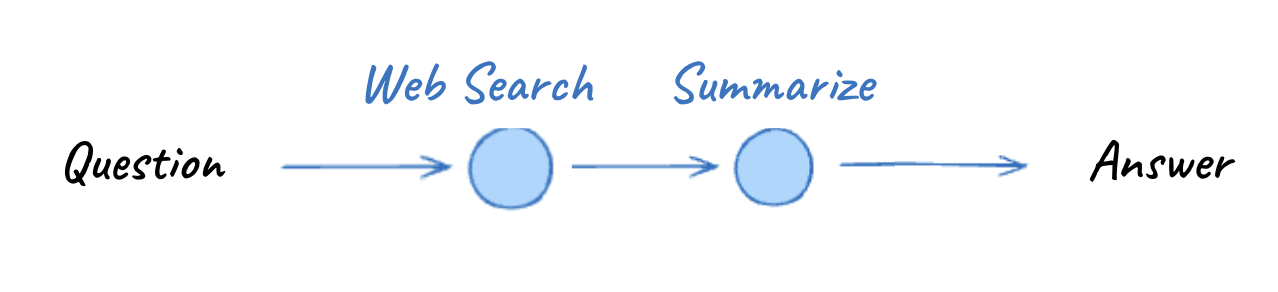

In this notebook, we're going to walk through setting up a simple chatbot in LangGraph. 

Throughout this process, we're going to show how LangSmith can be used to improve the developer experience for AI applications. 

Let's start by loading our environment variables from our .env file. 

In [1]:
import os, httpx
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=True)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Enable LangSmith tracing
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "eli5-explain-bot"

http_client = httpx.Client(verify=CA_BUNDLE)
async_client = httpx.AsyncClient(verify=CA_BUNDLE)

## Setup

Let's set up a tool called Tavily to allow our assistant to search the web when answering

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(max_results=1)

/var/folders/wr/xj2yx28s7xvg8trnrb4nc5_w0000gn/T/ipykernel_42069/632376592.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(max_results=1)


Let's design a prompt for RAG that we'll use throughout the notebook.

In [3]:
prompt = """You are a professor and expert in explaining complex topics in a way that is easy to understand. 
Your job is to answer the provided question so that even a 5 year old can understand it. 
You have provided with relevant background context to answer the question.

Question: {question} 

Context: {context}

Answer:"""
print("Prompt Template: ", prompt)

Prompt Template:  You are a professor and expert in explaining complex topics in a way that is easy to understand. 
Your job is to answer the provided question so that even a 5 year old can understand it. 
You have provided with relevant background context to answer the question.

Question: {question} 

Context: {context}

Answer:


## Creating Our Application

In [4]:
from groq import Groq
from langsmith import traceable

groq_client = Groq(api_key=os.environ["GROQ_API_KEY"])

@traceable
def search(question):
    web_docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in web_docs])
    return web_results
    
@traceable(run_type="llm")
def explain(question, context):
    formatted = prompt.format(question=question, context=context)
    
    completion = groq_client.chat.completions.create(
        messages=[
            {"role": "system", "content": formatted},
            {"role": "user", "content": question},
        ],
        model="llama-3.3-70b-versatile",
    )
    return completion.choices[0].message.content

@traceable
def explain_bot(question):
    context = search(question)
    answer = explain(question, context)
    return answer

## Testing Our Application

In [5]:
question = "What is LangChain?"
print(explain_bot(question))

Oh boy, are you going to love this!

Imagine you have a really smart robot friend who can answer questions and create things just by talking to it. This robot friend is like a super smart computer program that can understand what you say and do what you ask.

LangChain is like a special toolbox that helps people build and talk to these smart robot friends, called Large Language Models (LLMs). It makes it easier for them to understand what you want and give you better answers.

Think of it like a Lego box. Just like how you can use Lego blocks to build different things, LangChain is like a set of special blocks that helps people build and customize their smart robot friends to make them even smarter and more helpful!

So, LangChain is like a helper that makes these smart computer programs even better at understanding and talking to people, and it's free for anyone to use!


## Application Using LangGraph

Let's define the State for our Graph. We'll track the user's question, our application's generation, and the list of relevant documents.

In [8]:
from langchain_core.documents import Document
from typing import List
from typing_extensions import TypedDict
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, http_client=http_client, http_async_client=async_client)

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    """
    question: str
    documents: List[str]
    messages: List[str]

Great, now let's define the nodes of our graph

In [9]:
from langchain_core.messages import HumanMessage


def search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    question = state["question"]
    documents = state.get("documents", [])

    # Web search
    web_docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in web_docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

    
def explain(state: GraphState):
    """
    Generate response
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    question = state["question"]
    documents = state.get("documents", [])
    formatted = prompt.format(question=question, context="\n".join([d.page_content for d in documents]))
    generation = llm.invoke([HumanMessage(content=formatted)])
    return {"question": question, "messages": [generation]}

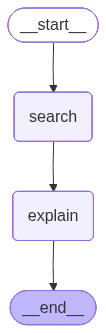

In [10]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(GraphState)
graph.add_node("explain", explain)
graph.add_node("search", search)
graph.add_edge(START, "search")
graph.add_edge("search", "explain")
graph.add_edge("explain", END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

## Testing Our Graph

Let's create a helper function to pretty print our results

In [11]:
def ask(question: str):
    for output in app.stream({"question": question}, stream_mode="updates"):
        if END in output or START in output:
            continue
        # Print any node outputs
        for key, value in output.items():
            if "messages" in value:
                print(value["messages"][0].content)


Finally, let's test our chatbot out and see how it works!

In [12]:
question = "What is complexity economics?"
ask(question)

Oh boy, are you ready for a fun explanation?

Imagine you have a big box of LEGOs, and inside that box, there are many different LEGO pieces like blocks, wheels, and windows. Each LEGO piece can connect with other pieces in different ways to create all sorts of things like a house, a car, or even a robot.

Now, think of the whole world as a giant box of LEGOs, and inside that box, there are many different "pieces" like people, companies, and governments. These pieces interact with each other in many different ways, like buying and selling things, working together, or even competing with each other.

Complexity economics is a way of studying how all these LEGO pieces (or people, companies, and governments) interact with each other and how they change over time. It's like trying to understand how the whole LEGO box works, and how all the different pieces fit together to create something new and exciting.

The special thing about complexity economics is that it recognizes that the world i